In [1]:
import os
import glob
import shutil

# Pacote para Dataframe e Plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de NLP
import re
import nltk
import spacy
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Carregando recursos
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
stop_word_pt = nltk.corpus.stopwords.words('portuguese')

try:
    nlp = spacy.load('pt_core_news_sm')
except OSError:
    print("Modleo Spacy não encontrado. Execute !python -m download pt_core_news_sm")
    nlp = None

In [3]:
# Definição das pastas de entrada e saída
PASTA_ENTRADA = 'processos'
PASTA_SAIDA = 'PII_anonimizados'

# Limpar e recriar a pasta de saída
if os.path.exists(PASTA_SAIDA):
    shutil.rmtree(PASTA_SAIDA)
os.makedirs(PASTA_SAIDA)

## Exploração de dados

In [4]:
# Carregar todo o corpus de texto em memória

corpus_total = []
nomes_arquivos = []

arquivos_analise = glob.glob(os.path.join(PASTA_ENTRADA, '*.txt'))
for caminho in arquivos_analise:
    with open(caminho, 'r', encoding='UTF-8') as f:
        corpus_total.append(f.read())
        nomes_arquivos.append(os.path.basename(caminho))

print(f"Total de arquivos carregados: {len(corpus_total)}")

Total de arquivos carregados: 10


In [5]:
# Vetorização inicial
vec_analise = CountVectorizer(stop_words=stop_word_pt, min_df=1)
X_analise = vec_analise.fit_transform(corpus_total)
X_analise.shape

(10, 427)

In [6]:
X_analise

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1057 stored elements and shape (10, 427)>

In [7]:
# somar frequências globais
soma_palavras = X_analise.sum(axis=0)

palavras_freq = [(word, soma_palavras[0, idx]) for word,idx in vec_analise.vocabulary_.items()]


In [8]:
# Criar Dataframe
df_freq_global = pd.DataFrame(palavras_freq, columns=['Termo','Frequência'])
df_freq_global = df_freq_global.sort_values(by='Frequência', ascending=False)

In [9]:
# Mostrar tabela de frequência
df_freq_global.head(30)

,Termo,Frequência
78,00,27
12,nº,22
15,2023,21
4,direito,21
43,ação,20
18,autor,20
81,requer,20
35,email,20
55,código,13
76,valor,13


Text(0.5, 1.0, 'Top 30 palavras mais frequentes')

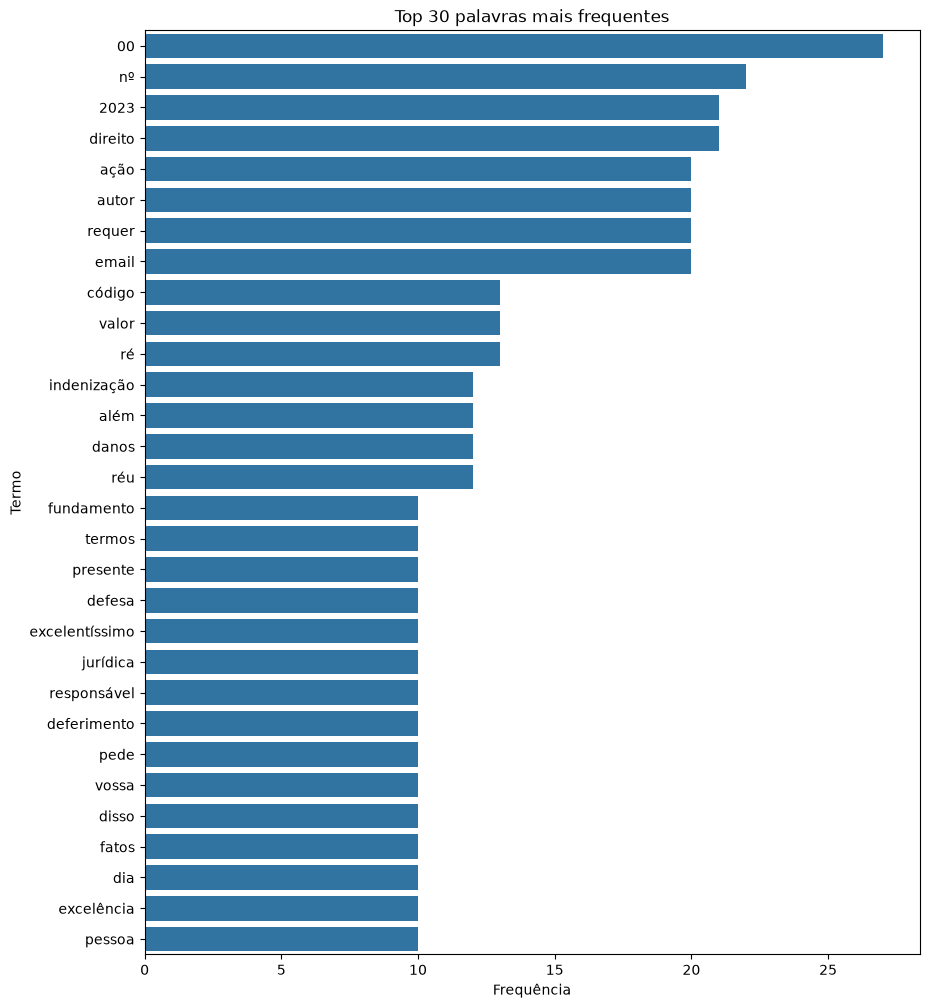

In [10]:
# Mostrar um plot

plt.figure(figsize=(10,12))
sns.barplot(data=df_freq_global.head(30),x="Frequência", y="Termo")
plt.title("Top 30 palavras mais frequentes")

In [11]:
# Criar uma lista de stop words "jurídicas"

stopwords_juridicas = []
TOP_N = 30

for palavra, freq in palavras_freq:
    if not palavra.isdigit():
        stopwords_juridicas.append(palavra)
    if len(stopwords_juridicas) >= TOP_N:
        break

In [12]:
# Criar lista consolidando stop words
stop_words_juridico = stop_word_pt + stopwords_juridicas
len(stop_words_juridico)

237

## Criação das tarefas de NLP

In [13]:
# Extrair entidades usando RegEX
def extrair_entidades(texto):
    dados = {
        'CPFs': [],
        'Emails': [],
        'Datas': [],
        'Valores (R$)': [],
        'Legislação': []
    }

    # Extrair CPFs
    dados['CPFs'] = re.findall(r'\d{3}\.\d{3}\.\d{3}-\d{2}', texto)

    # Extrair Emails 
    dados['Emails'] = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', texto)

    # Extrair Datas
    datas_simples = re.findall(r'\d{2}/\d{2}/\d{4}', texto)
    dados['Datas'].extend(datas_simples)

    # Extrair Valores
    dados['Valores'] = re.findall(r'(?<=R\$\s)[\d.,]+', texto)

    # Extrair Legislação
    dados['Legislação'] = re.findall(r'Lei nº? \d+(?:\.\d+)?', texto, flags=re.IGNORECASE)

    return dados

In [14]:
# Identificar tema do processo
def identificar_tema(texto):
    pattern = r'(?<=DOS FATOS)([\s\S]*?)(?=O valor|R\$|DOS PEDIDOS)'
    match = re.search(pattern, texto, flags=re.IGNORECASE)
    if not match:
        return "Seção DOS FATOS não foi encontrada"

    texto_fatos = match.group(0).strip()

    # Limpeza básica
    texto_limpo = re.sub(r'[^\w\s]', '', texto_fatos.lower())
    texto_limpo = re.sub(r'\d+', '', texto_limpo)
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()

    vectorizer = CountVectorizer(
        stop_words=stop_words_juridico,
        ngram_range=(1, 2),
        max_features=15
    )

    try:
        X = vectorizer.fit_transform([texto_limpo])
        vocab = vectorizer.get_feature_names_out()
        contagens = X.toarray().sum(axis=0)

        df_freq = pd.DataFrame({'termo': vocab, 'freq': contagens}).sort_values(by='freq', ascending=False)
        
        return ",".join(df_freq['termo'].head(3).tolist())
    except Exception:
        return "Conteúdo insuficiente para análise"

In [15]:
# Anomimizar Texto
def anomimizar_texto(texto):

    # Regex para CPF e E-Mails
    txt = re.sub(r'\d{3}\.\d{3}\.\d{3}-\d{2}', '[CPF]', texto)
    txt = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', txt)

    # NER (Named Entity Recognition) - Spacy
    if nlp:
        doc = nlp(txt)
        for ent in reversed(doc.ents):
            if ent.label_ == 'PER':
                txt = txt[:ent.start_char] + '[PESSOA]' + txt[ent.end_char:]
            if ent.label_ == 'ORG':
                txt = txt[:ent.start_char] + '[EMPRESA]' + txt[ent.end_char:]

    return txt

## Loop principal para Pipeline NLP

In [16]:
relatorio_geral = []

lista_arquivos = glob.glob(os.path.join(PASTA_ENTRADA, '*.txt'))
for caminho in lista_arquivos:
    nome_arquivo = os.path.basename(caminho)

    with open(caminho, 'r', encoding='UTF-8') as f:
        texto_bruto = f.read()

        #Extração de entidades
        dados_extraidos = extrair_entidades(texto_bruto)

        # Identificar tema
        tema_identificado = identificar_tema(texto_bruto)

        # Anonimizar Texto
        texto_anonimizado = anomimizar_texto(texto_bruto)

        # Salvar arquivo
        caminho_saida = os.path.join(PASTA_SAIDA,f"save_{nome_arquivo}")

        with open(caminho_saida, 'w', encoding="UTF-8") as f:
            f.write(texto_anonimizado)
        
        registro = {
            'Nome do Arquivo': nome_arquivo,
            'Tema': tema_identificado,
            'CPFs': ", ".join(dados_extraidos['CPFs']),
            'Emails': ", ".join(dados_extraidos['Emails']),
            'Datas': ", ".join(dados_extraidos['Datas']),
            'Valores': ", ".join(dados_extraidos['Valores']),
            'Legislações': ", ".join(dados_extraidos['Legislação']),
            'Arquivo Saída': caminho_saida
        }

        relatorio_geral.append(registro)

        print(f"[OK] Processando: {nome_arquivo} -> Salvo em {PASTA_SAIDA}")
    
    print("\nProcessamento concluído!")




[OK] Processando: processo_009.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_002.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_007.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_001.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_003.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_004.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_005.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_006.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_008.txt -> Salvo em PII_anonimizados

Processamento concluído!
[OK] Processando: processo_010.txt -> Salvo em PII_anonimizados

Processamento concluído!


In [17]:
df_resultados = pd.DataFrame(relatorio_geral)
df_resultados = df_resultados.sort_values(by='Nome do Arquivo')
df_resultados

,Nome do Arquivo,Tema,CPFs,Emails,Datas,Valores,Legislações,Arquivo Saída
3,processo_001.txt,"autora,abusivas contrato,abusivas",234.567.890-11,maria.santos@email.com,22/04/2023,"8.450,00., 16.900,00,",Lei nº 8.078,PII_anonimizados/save_processo_001.txt
1,processo_002.txt,"adquirido,adquirido notificou,comprovados",345.678.901-22,carlos.ferreira@email.com,10/05/2023,"12.800,00., 12.800,00",,PII_anonimizados/save_processo_002.txt
4,processo_003.txt,"autora,procedimento,ans",456.789.012-33,ana.rodrigues@email.com,18/06/2023,"22.500,00., 15.000,00., 37.500,00,",Lei nº 9.656,PII_anonimizados/save_processo_003.txt
5,processo_004.txt,"cancelamento,cancelamento estorno,cobrança",567.890.123-44,ricardo.costa@email.com,30/07/2023,"3.890,75., 8.000,00., 8.000,00.",,PII_anonimizados/save_processo_004.txt
6,processo_005.txt,"autora,adquiriu,adquiriu móveis",678.901.234-55,fernanda.souza@email.com,05/08/2023,"18.600,00., 6.000,00., 24.600,00.",,PII_anonimizados/save_processo_005.txt
7,processo_006.txt,"aparelhos,aparelhos eletrônicos,comprovados",789.012.345-66,pedro.martins@email.com,14/09/2023,"9.750,00., 5.000,00., 14.750,00,",,PII_anonimizados/save_processo_006.txt
2,processo_007.txt,"autora,abusivos,autora pacote",890.123.456-77,juliana.araujo@email.com,25/10/2023,"11.300,00., 7.000,00., 18.300,00.",,PII_anonimizados/save_processo_007.txt
8,processo_008.txt,"abusivas,abusivas previstas,anual",901.234.567-88,marcos.teixeira@email.com,12/11/2023,"2.400,00., 2.400,00.",,PII_anonimizados/save_processo_008.txt
0,processo_009.txt,"autora,acionou assistência,acionou",012.345.678-99,beatriz.cardoso@email.com,08/12/2023,"4.200,00., 3.000,00., 3.000,00",,PII_anonimizados/save_processo_009.txt
9,processo_010.txt,"apenas,apenas após,após",112.233.445-00,rafael.pereira@email.com,20/01/2024,"14.800,00., 14.800,00,",,PII_anonimizados/save_processo_010.txt
